In [1]:
import os
import pandas as pd
import pickle

In [2]:
dataset_map = {
    "mmlu": "MMLU",
    "squadv2": "SQuADv2.0",
    "truthful_qa": "TruthfulQA"
}

model_name_map = {
    "Llama-3.1-8B-Instruct": "Llama-3.1-8B-Inst.",
    "Meta-Llama-3-8B-Instruct": "Llama-3-8B-Inst.",
    "Qwen2.5-7B-Instruct": "Qwen2.5-7B-Inst.",
    "Qwen3-8B": "Qwen3-8B-Inst.",
    "Mistral-7B-Instruct-v0.3": "Mistral-7B-Inst.",
    "gpt-oss-20b": "GPT-OSS-20B",
}

In [3]:
def _leaf_dirs(root_dir):
    leaf_dirs = []
    for root, dirs, files in os.walk(root_dir):
        if not dirs:
            leaf_dirs.append(root)
    return sorted(leaf_dirs)

def extract_mu(string: str) -> float:
    # Extract the number after "mu=" and before the next comma or end of string
    import re
    match = re.search(r"mu=([\d\.]+)", string)
    if match:
        return float(match.group(1))
    else:
        raise ValueError(f"Could not extract mu from string: {string}")


models = []
datasets = []

direct_aurocs = []
direct_eces = []
direct_fd = []

hedged_aurocs = []
hedged_eces = []
hedged_fd = []

all_direct_qa_confs = []
all_hedged_qa_confs = []

# Length tracking for weighted averages
sample_lengths = []
dataset_instance_counts = {dataset: 0 for dataset in dataset_map.keys()}

for dataset in dataset_map.keys():
    direct_qa_dir = f"/hdd/ivny/results/{dataset}/direct_qa_unified_lc"
    hedged_qa_dir = f"/hdd/ivny/results/{dataset}/hedged_qa_unified_lc"

    direct_qa_leaf_dirs = _leaf_dirs(direct_qa_dir)
    hedged_qa_leaf_dirs = _leaf_dirs(hedged_qa_dir)

    for direct_qa_leaf_dir, hedged_qa_leaf_dir in zip(direct_qa_leaf_dirs, hedged_qa_leaf_dirs):
        direct_qa_conf_path = os.path.join(direct_qa_leaf_dir, "eval_details.csv")
        hedged_qa_conf_path = os.path.join(hedged_qa_leaf_dir, "eval_details.csv")

        direct_mus = pd.read_csv(direct_qa_conf_path)["confidence_0"].apply(extract_mu).tolist()
        hedged_mus = pd.read_csv(hedged_qa_conf_path)["confidence_0"].apply(extract_mu).tolist()

        direct_metrics = pd.read_csv(os.path.join(direct_qa_leaf_dir, "eval_metrics.csv"), header=0)
        hedged_metrics = pd.read_csv(os.path.join(hedged_qa_leaf_dir, "eval_metrics.csv"), header=0)

        # Use paired sample count so direct and hedged weighting stays aligned
        paired_sample_count = min(len(direct_mus), len(hedged_mus))

        models += [os.path.basename(direct_qa_leaf_dir)]
        datasets += [dataset]
        direct_aurocs += [direct_metrics["dAUROC"].iloc[0]]
        direct_eces += [direct_metrics["generalised_ece"].iloc[0]]
        direct_fd += [direct_metrics["faithfulness_divergence"].iloc[0]]

        hedged_aurocs += [hedged_metrics["dAUROC"].iloc[0]]
        hedged_eces += [hedged_metrics["generalised_ece"].iloc[0]]
        hedged_fd += [hedged_metrics["faithfulness_divergence"].iloc[0]]

        sample_lengths += [paired_sample_count]
        dataset_instance_counts[dataset] += paired_sample_count

        all_direct_qa_confs += direct_mus
        all_hedged_qa_confs += hedged_mus

dataset_instance_counts

{'mmlu': 56168, 'squadv2': 47492, 'truthful_qa': 3268}

mkdir -p failed for path /ssd/ivn/cache/matplotlib: [Errno 107] Transport endpoint is not connected: '/ssd/ivn/cache/matplotlib'
Matplotlib created a temporary cache directory at /tmp/matplotlib-_r23bj1_ because there was an issue with the default path (/ssd/ivn/cache/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


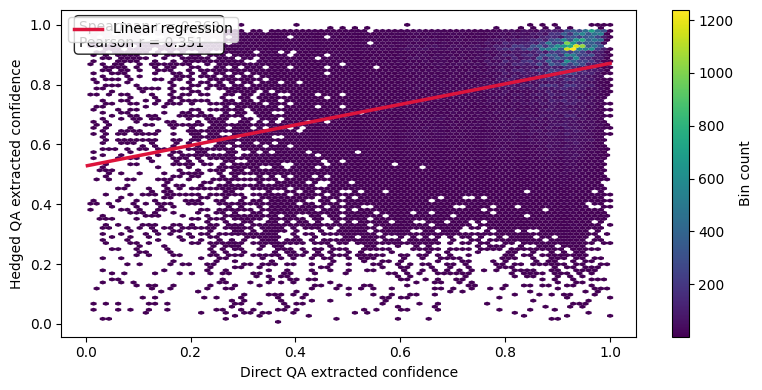

Spearman r: 0.368580
Spearman p-value: 0
Pearson r: 0.350817


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress, spearmanr

x = np.asarray(all_direct_qa_confs, dtype=float)
y = np.asarray(all_hedged_qa_confs, dtype=float)
mask = np.isfinite(x) & np.isfinite(y)
x = x[mask]
y = y[mask]

slope, intercept, pearson_r, p_value, std_err = linregress(x, y)
spearman_r, spearman_p = spearmanr(x, y)

fig, ax = plt.subplots(figsize=(8, 4))
hexbin = ax.hexbin(
    x,
    y,
    gridsize=85,
    mincnt=1,
    cmap="viridis",
    linewidths=0,
)

x_line = np.linspace(x.min(), x.max(), 200)
y_line = intercept + slope * x_line
ax.plot(x_line, y_line, color="crimson", linewidth=2.5, label="Linear regression")

ax.set_xlabel("Direct QA extracted confidence")
ax.set_ylabel("Hedged QA extracted confidence")
# ax.set_title("Direct QA vs Hedged QA extracted confidence")
ax.legend(loc="upper left")

cbar = fig.colorbar(hexbin, ax=ax)
cbar.set_label("Bin count")

ax.text(
    0.03,
    0.97,
    f"Spearman r = {spearman_r:.3f}\nPearson r = {pearson_r:.3f}",
    transform=ax.transAxes,
    va="top",
    ha="left",
    bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.85},
)

plt.tight_layout()
plt.show()

print(f"Spearman r: {spearman_r:.6f}")
print(f"Spearman p-value: {spearman_p:.6g}")
print(f"Pearson r: {pearson_r:.6f}")

Spearman r: 0.368580
Spearman p-value: 0
Pearson r: 0.350817


,metric,direct_weighted_avg,hedged_weighted_avg
0,Generalised ECE,0.300667,0.263878
1,Faithfulness Divergence,2.203726,1.695563


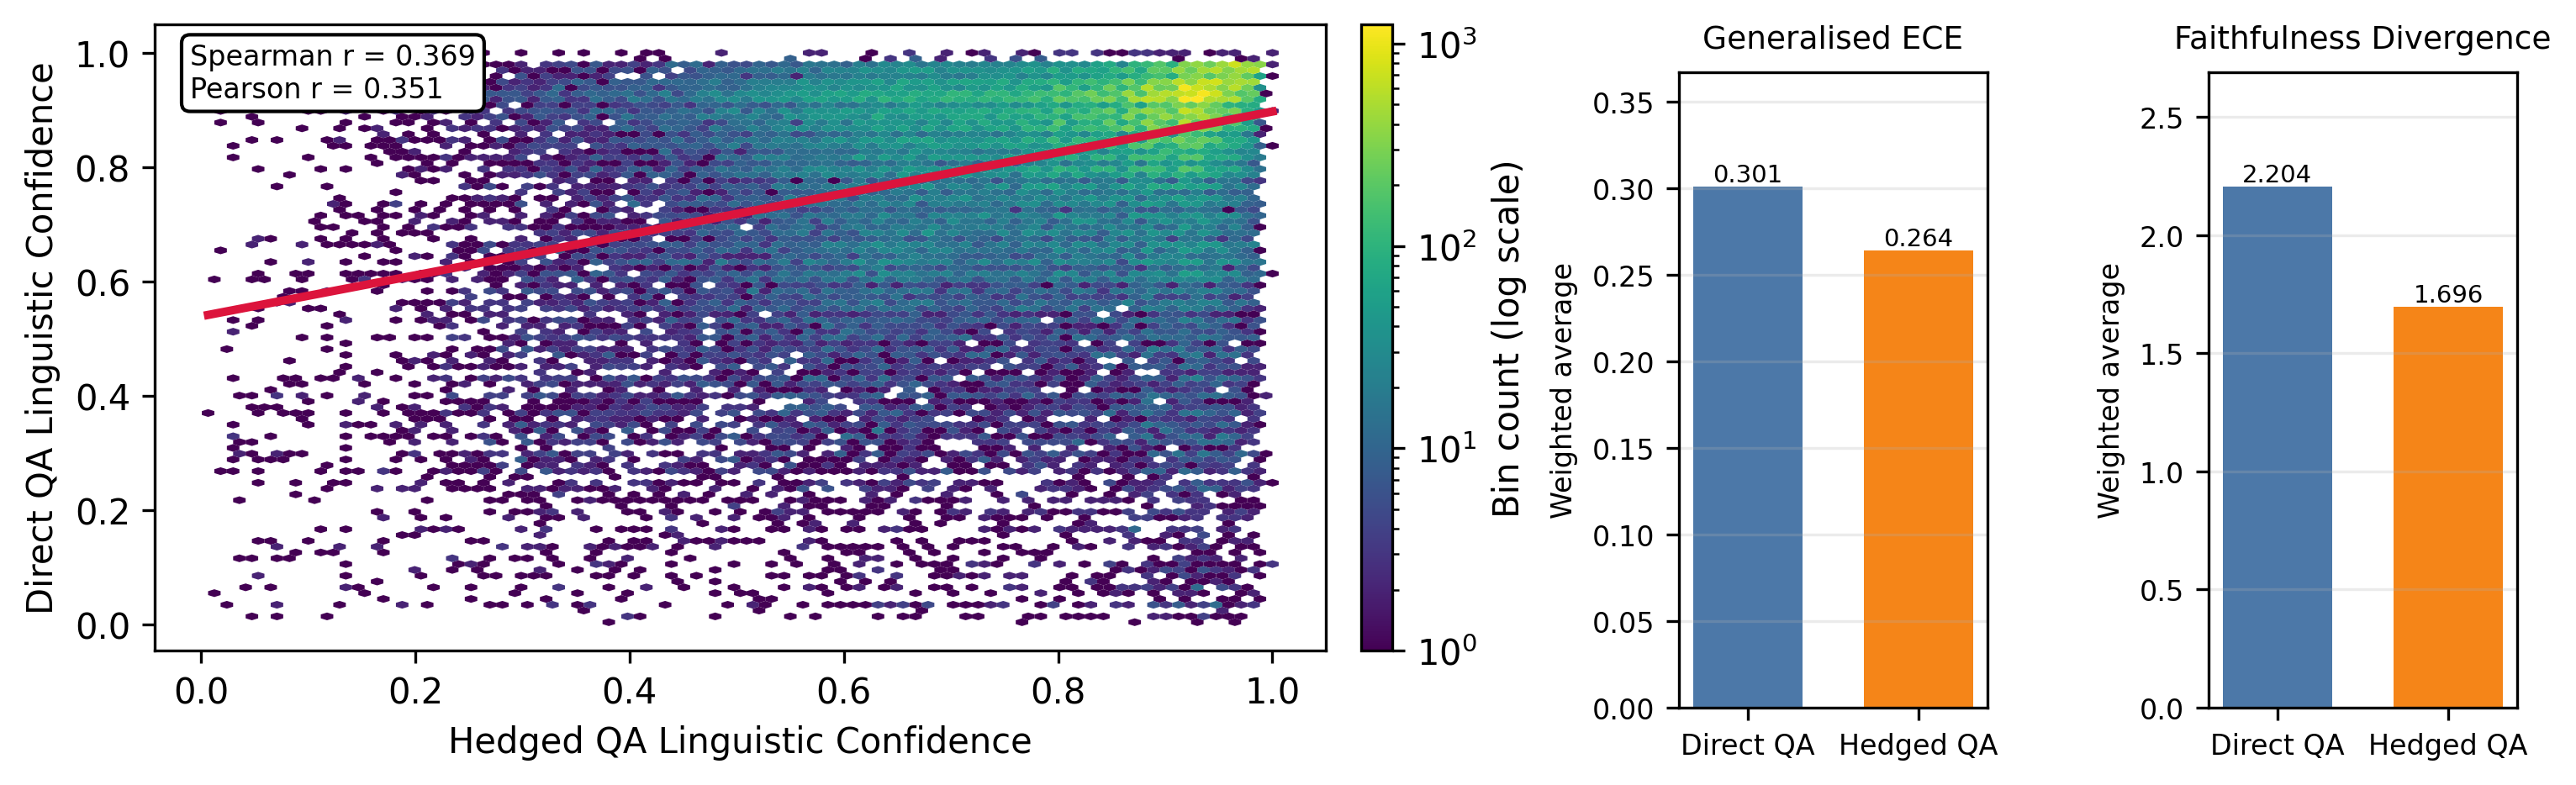

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress, spearmanr

metrics_df = pd.DataFrame(
    {
        "dataset": datasets,
        "sample_count": sample_lengths,
        "direct_auroc": direct_aurocs,
        "direct_ece": direct_eces,
        "direct_fd": direct_fd,
        "hedged_auroc": hedged_aurocs,
        "hedged_ece": hedged_eces,
        "hedged_fd": hedged_fd,
    }
)

weights = metrics_df["sample_count"].to_numpy(dtype=float)
if np.any(weights < 0):
    raise ValueError("sample_count contains negative values.")
if np.all(weights == 0):
    raise ValueError("All sample_count values are zero; cannot compute weighted averages.")

metric_specs = [
    ("Generalised ECE", "direct_ece", "hedged_ece", "Weighted average"),
    ("Faithfulness Divergence", "direct_fd", "hedged_fd", "Weighted average"),
]

weighted_summary = pd.DataFrame(
    {
        "metric": [name for name, _, _, _ in metric_specs],
        "direct_weighted_avg": [
            np.average(metrics_df[d_col], weights=weights) for _, d_col, _, _ in metric_specs
        ],
        "hedged_weighted_avg": [
            np.average(metrics_df[h_col], weights=weights) for _, _, h_col, _ in metric_specs
        ],
    }
)

# Correlation inputs
x = np.asarray(all_direct_qa_confs, dtype=float)
y = np.asarray(all_hedged_qa_confs, dtype=float)
mask = np.isfinite(x) & np.isfinite(y)
x = x[mask]
y = y[mask]

# Fit in swapped coordinate system: y->x axis, x->y axis
slope, intercept, pearson_r, _, _ = linregress(y, x)
spearman_r, spearman_p = spearmanr(x, y)

# Combined layout: left correlation plot, right weighted bar plots
fig = plt.figure(figsize=(10, 3), dpi=300, constrained_layout=True)
gs = fig.add_gridspec(1, 2, width_ratios=[1.35, 1.15])

# Left: binned correlation + regression (axes swapped)
ax_corr = fig.add_subplot(gs[0, 0])
hexbin = ax_corr.hexbin(
    y,
    x,
    gridsize=85,
    mincnt=1,
    cmap="viridis",
    linewidths=0,
    bins="log",
)

x_line = np.linspace(y.min(), y.max(), 200)
y_line = intercept + slope * x_line
ax_corr.plot(x_line, y_line, color="crimson", linewidth=2.4)

ax_corr.set_xlabel("Hedged QA Linguistic Confidence")
ax_corr.set_ylabel("Direct QA Linguistic Confidence")

cbar = fig.colorbar(hexbin, ax=ax_corr, fraction=0.046, pad=0.03)
cbar.set_label("Bin count (log scale)")

ax_corr.text(
    0.03,
    0.97,
    f"Spearman r = {spearman_r:.3f}\nPearson r = {pearson_r:.3f}",
    transform=ax_corr.transAxes,
    va="top",
    ha="left",
    bbox={"boxstyle": "round", "facecolor": "white", "alpha": 1},
    fontsize=8,
)

# Right: weighted bars with independent y-scales (ECE and FD only)
gs_right = gs[0, 1].subgridspec(1, 2, wspace=0.08)
bar_colors = {"direct": "#4C78A8", "hedged": "#F58518"}

for i, (metric_name, _, _, y_label) in enumerate(metric_specs):
    ax = fig.add_subplot(gs_right[0, i])
    row = weighted_summary[weighted_summary["metric"] == metric_name].iloc[0]
    vals = [row["direct_weighted_avg"], row["hedged_weighted_avg"]]

    bars = ax.bar(
        [0, 1],
        vals,
        width=0.64,
        color=[bar_colors["direct"], bar_colors["hedged"]],
    )

    ymax = max(vals)
    ax.set_ylim(0, ymax * 1.22 if ymax > 0 else 1.0)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Direct QA", "Hedged QA"], rotation=0, fontsize=8)
    ax.set_title(metric_name, pad=7, fontsize=9)
    ax.set_ylabel(y_label, fontsize=8)
    ax.grid(axis="y", alpha=0.25)
    ax.tick_params(axis="y", labelsize=8)

    for b in bars:
        h = b.get_height()
        ax.text(
            b.get_x() + b.get_width() / 2,
            h,
            f"{h:.3f}",
            ha="center",
            va="bottom",
            fontsize=7,
        )

# fig.suptitle("Prompt comparison: correlation and weighted metrics", fontsize=11)
plt.savefig("prompt_comparison_corr_calibration.pdf", dpi=300, bbox_inches="tight")

print(f"Spearman r: {spearman_r:.6f}")
print(f"Spearman p-value: {spearman_p:.6g}")
print(f"Pearson r: {pearson_r:.6f}")

weighted_summary